<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 50%, #f093fb 100%);
            padding: 40px 20px;
            border-radius: 15px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.3);
            text-align: center;
            margin-bottom: 25px;">
    <h1 style="color: white;
               font-size: 42px;
               font-weight: 800;
               margin: 0;
               text-shadow: 2px 2px 8px rgba(0,0,0,0.3);
               font-family: 'Segoe UI', sans-serif;">
        🏠 House Price Prediction
    </h1>
    <p style="color: #f0f0f0;
              font-size: 18px;
              margin-top: 10px;
              font-style: italic;
              letter-spacing: 1px;">
        📊 An End-to-End Machine Learning Regression Project
    </p>
</div>

<!-- Libraries Used Section -->
<div style="background: #1e1e2f;
            padding: 20px;
            border-radius: 12px;
            margin-bottom: 20px;">
    <h3 style="color: #f093fb; text-align:center; font-family:'Segoe UI', sans-serif;">
        🧰 Libraries Used
    </h3>
    <div style="text-align:center;">
        <span style="background:#667eea; color:white; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">🐍 Python</span>
        <span style="background:#764ba2; color:white; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">🐼 Pandas</span>
        <span style="background:#f093fb; color:white; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">🔢 NumPy</span>
        <span style="background:#4facfe; color:white; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">📉 Matplotlib</span>
        <span style="background:#43e97b; color:white; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">🌊 Seaborn</span>
        <span style="background:#fa709a; color:white; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">🤖 Scikit-Learn</span>
        <span style="background:#feb47b; color:white; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">📦 Joblib</span>
    </div>
</div>

<!-- Concepts Used Section -->
<div style="background: #1e1e2f;
            padding: 20px;
            border-radius: 12px;
            margin-bottom: 20px;">
    <h3 style="color: #43e97b; text-align:center; font-family:'Segoe UI', sans-serif;">
        💡 Concepts Used
    </h3>
    <div style="text-align:center;">
        <span style="background:#2c3e50; color:#f0f0f0; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">🧹 Data Cleaning</span>
        <span style="background:#2c3e50; color:#f0f0f0; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">🕳️ Missing Value Imputation</span>
        <span style="background:#2c3e50; color:#f0f0f0; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">🏷️ Label Encoding</span>
        <span style="background:#2c3e50; color:#f0f0f0; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">📏 Feature Scaling</span>
        <span style="background:#2c3e50; color:#f0f0f0; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">✂️ Train-Test Split</span>
        <span style="background:#2c3e50; color:#f0f0f0; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">📈 Regression Models</span>
        <span style="background:#2c3e50; color:#f0f0f0; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">🎯 Model Evaluation (R², MAE, RMSE)</span>
        <span style="background:#2c3e50; color:#f0f0f0; padding:6px 14px; border-radius:20px; margin:5px; display:inline-block; font-size:14px;">💾 Model Serialization</span>
    </div>
</div>

# Import and Set up

In [94]:
# EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


# Setup plots
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 4)

# Filter warnings
import warnings as w
w.filterwarnings('ignore')

# Pickle (save model and parameters)
import pickle

# Time stamp
import time
print(f"Last Update : {time.asctime()}")

Last Update : Sat Aug  8 07:33:48 2026


In [45]:
import os

os.makedirs('/kaggle/working/plots', exist_ok=True)
os.makedirs('/kaggle/working/models', exist_ok=True)

# Load Datset

In [46]:
df = pd.read_csv('/kaggle/input/datasets/engraamirjamil/house-price-prediction/House_Price_Prediction_1500_Records.csv')

In [47]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Floors,Age,Garage,LocationScore,DistanceToCity_km,Condition,Price
0,2728.0,1.0,4.0,2.0,7.0,0.0,3.0,NaN,Fair,547397
1,3121.0,1.0,5.0,3.0,31.0,1.0,1.0,3.4,Excellent,609297
2,3930.0,2.0,4.0,2.0,31.0,3.0,8.0,12.7,Excellent,831827
3,1298.0,3.0,4.0,3.0,34.0,3.0,4.0,12.7,Fair,306564
4,1055.0,6.0,3.0,NaN,5.0,1.0,10.0,36.2,Fair,317816


<h1 style="background: linear-gradient(135deg, #ff6a00 0%, #ee0979 50%, #8e2de2 100%);
           -webkit-background-clip: text;
           -webkit-text-fill-color: transparent;
           background-clip: text;
           font-size: 40px;
           font-weight: 800;
           text-align: center;
           font-family: 'Segoe UI', sans-serif;
           padding: 15px 0;
           margin: 0;">
    🔍 Exploratory Data Analysis (EDA)
</h1>

## Number of Rows and columns

In [48]:
df.shape

(1500, 10)

In [49]:
df.columns

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Floors', 'Age', 'Garage',
       'LocationScore', 'DistanceToCity_km', 'Condition', 'Price'],
      dtype='object')

## Entire Information

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area_sqft          1374 non-null   float64
 1   Bedrooms           1376 non-null   float64
 2   Bathrooms          1375 non-null   float64
 3   Floors             1379 non-null   float64
 4   Age                1394 non-null   float64
 5   Garage             1363 non-null   float64
 6   LocationScore      1385 non-null   float64
 7   DistanceToCity_km  1376 non-null   float64
 8   Condition          1371 non-null   object 
 9   Price              1500 non-null   int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 117.3+ KB


## Statistical Summary

In [51]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area_sqft,1374.0,NaN,NaN,NaN,2719.296943,1262.733349,607.0,1633.5,2681.0,3832.75,5000.0
Bedrooms,1376.0,NaN,NaN,NaN,3.516715,1.688381,1.0,2.0,4.0,5.0,6.0
Bathrooms,1375.0,NaN,NaN,NaN,3.013091,1.426961,1.0,2.0,3.0,4.0,5.0
Floors,1379.0,NaN,NaN,NaN,2.008702,0.809906,1.0,1.0,2.0,3.0,3.0
Age,1394.0,NaN,NaN,NaN,24.982783,14.791676,0.0,12.0,25.0,37.75,50.0
Garage,1363.0,NaN,NaN,NaN,1.471753,1.105872,0.0,0.0,1.0,2.0,3.0
LocationScore,1385.0,NaN,NaN,NaN,5.483032,2.906025,1.0,3.0,6.0,8.0,10.0
DistanceToCity_km,1376.0,NaN,NaN,NaN,20.632703,11.447891,1.0,10.4,20.25,30.6,40.0
Condition,1371,4,Fair,347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1500.0,NaN,NaN,NaN,562735.832667,230110.162296,104687.0,366822.5,556069.0,748897.75,1054839.0


## Check Missing values

In [52]:
df.isna().sum()

Area_sqft            126
Bedrooms             124
Bathrooms            125
Floors               121
Age                  106
Garage               137
LocationScore        115
DistanceToCity_km    124
Condition            129
Price                  0
dtype: int64

## Check Datatypes

In [53]:
df.dtypes

Area_sqft            float64
Bedrooms             float64
Bathrooms            float64
Floors               float64
Age                  float64
Garage               float64
LocationScore        float64
DistanceToCity_km    float64
Condition             object
Price                  int64
dtype: object

## Handle Missing Values

In [54]:
# ================= HANDLE MISSING VALUES =================

# --- Continuous numeric columns: fill with median ---
numeric_cols = ['Area_sqft', 'Age', 'LocationScore', 'DistanceToCity_km']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# --- Discrete/count columns: fill with mode ---
discrete_cols = ['Bedrooms', 'Bathrooms', 'Floors', 'Garage']
for col in discrete_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# --- Condition column: categorical -> convert to ordinal numbers ---
print("\nCondition unique values (before mapping):", df['Condition'].unique())

condition_map = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Excellent': 4
}
df['Condition'] = df['Condition'].map(condition_map)

# Agar mapping ke baad bhi koi NaN reh jaye (spelling mismatch waghera), median se fill karein
df['Condition'] = df['Condition'].fillna(df['Condition'].median())

# --- Price (target variable): drop rows where price is missing ---
df = df.dropna(subset=['Price'])

# ================= CHECK MISSING VALUES AFTER =================
print("\nMissing values AFTER cleaning:\n", df.isnull().sum())

# ================= FINAL CHECK =================
print("\nFinal shape:", df.shape)
print("\nData types:\n", df.dtypes)


Condition unique values (before mapping): ['Fair' 'Excellent' 'Poor' nan 'Good']

Missing values AFTER cleaning:
 Area_sqft            0
Bedrooms             0
Bathrooms            0
Floors               0
Age                  0
Garage               0
LocationScore        0
DistanceToCity_km    0
Condition            0
Price                0
dtype: int64

Final shape: (1500, 10)

Data types:
 Area_sqft            float64
Bedrooms             float64
Bathrooms            float64
Floors               float64
Age                  float64
Garage               float64
LocationScore        float64
DistanceToCity_km    float64
Condition            float64
Price                  int64
dtype: object


## Duplicate Rows check and remove

In [55]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


## Again Check Statistical Summary

In [56]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Floors,Age,Garage,LocationScore,DistanceToCity_km,Condition,Price
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1.500000e+03
mean,2716.080000,3.556667,3.095333,2.008000,24.984000,1.428667,5.522667,20.601067,2.545333,5.627358e+05
std,1208.545184,1.622512,1.393152,0.776534,14.259101,1.062857,2.795716,10.964683,1.074266,2.301102e+05
min,607.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.046870e+05
25%,1736.750000,2.000000,2.000000,1.000000,13.000000,1.000000,3.000000,11.200000,2.000000,3.668225e+05
50%,2681.000000,4.000000,3.000000,2.000000,25.000000,1.000000,6.000000,20.250000,3.000000,5.560690e+05
75%,3725.500000,5.000000,4.000000,3.000000,37.000000,2.000000,8.000000,29.700000,3.000000,7.488978e+05
max,5000.000000,6.000000,5.000000,3.000000,50.000000,3.000000,10.000000,40.000000,4.000000,1.054839e+06


## Again Check Datatypes

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area_sqft          1500 non-null   float64
 1   Bedrooms           1500 non-null   float64
 2   Bathrooms          1500 non-null   float64
 3   Floors             1500 non-null   float64
 4   Age                1500 non-null   float64
 5   Garage             1500 non-null   float64
 6   LocationScore      1500 non-null   float64
 7   DistanceToCity_km  1500 non-null   float64
 8   Condition          1500 non-null   float64
 9   Price              1500 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 117.3 KB


## Visualization

### Histogram

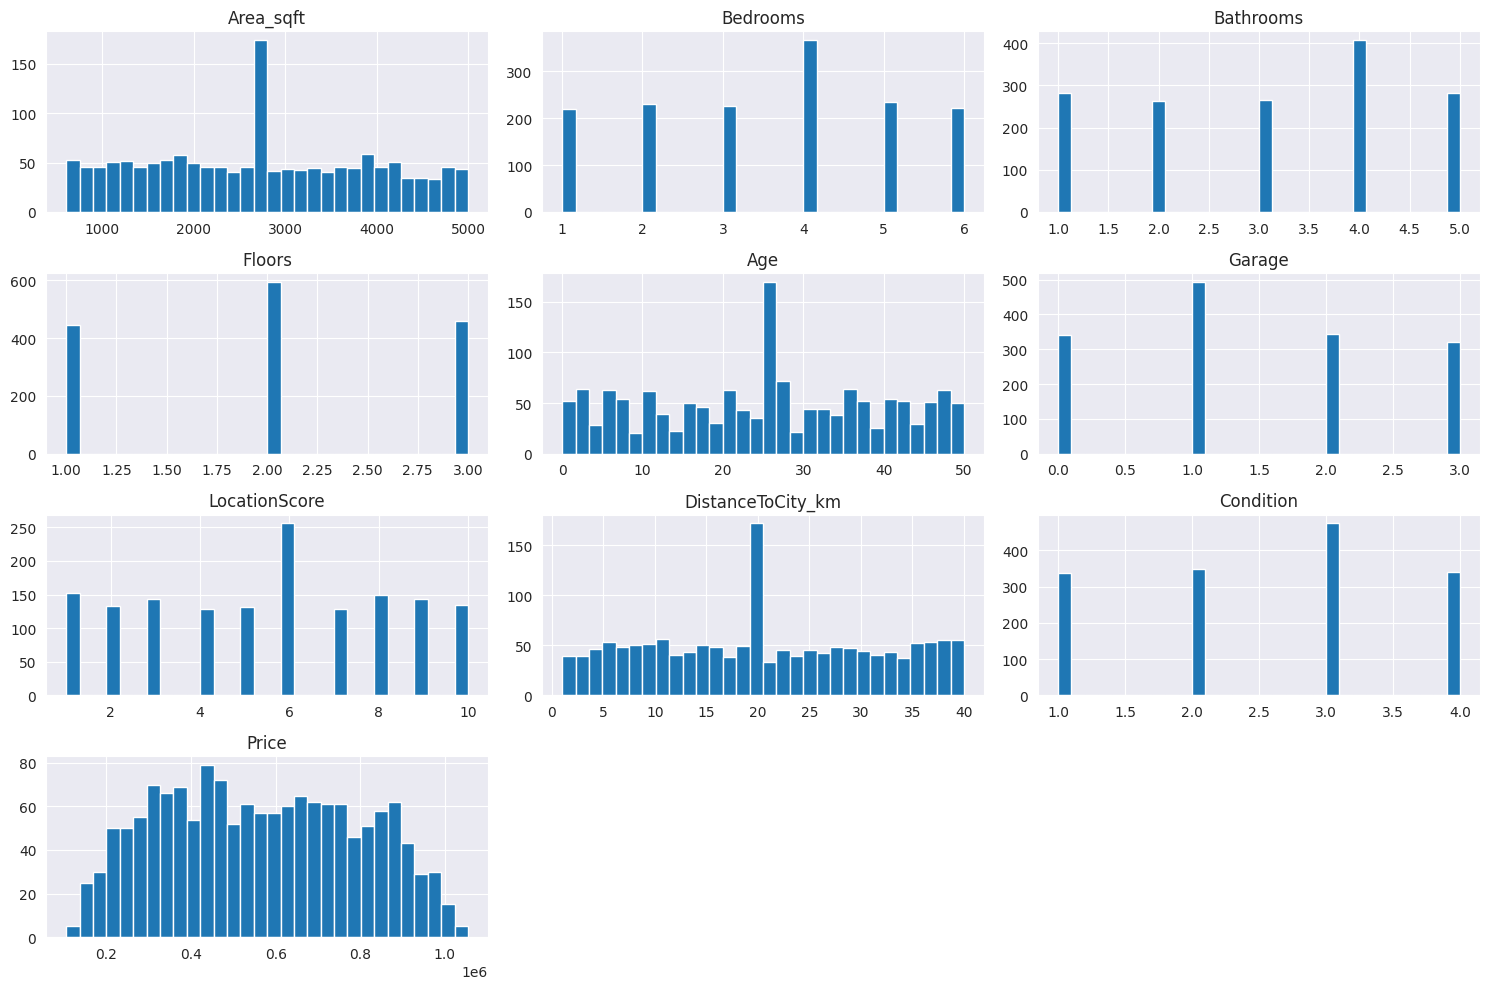

In [58]:
df.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.savefig('/kaggle/working/plots/histogram.png')
plt.show()

### Box Plots

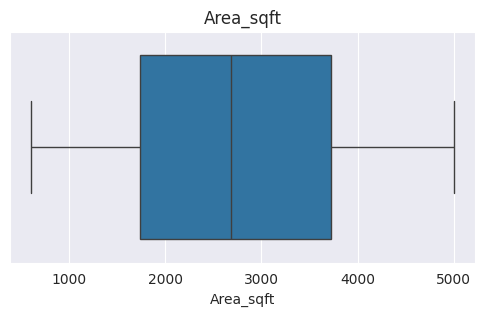

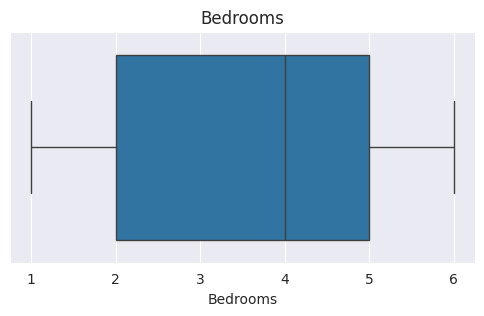

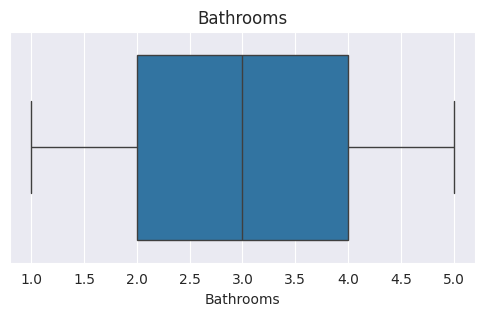

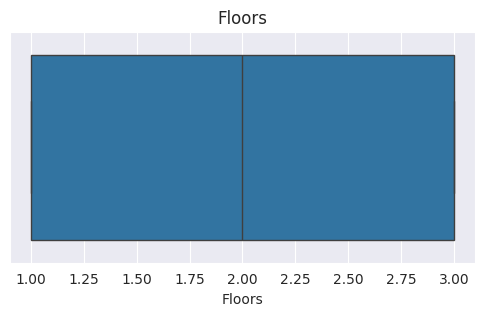

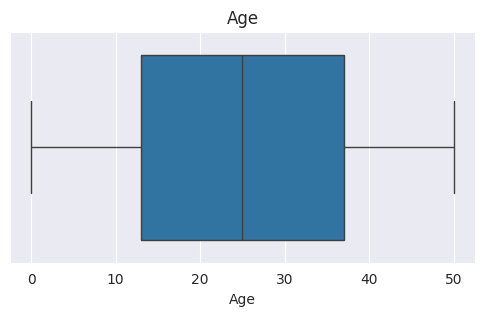

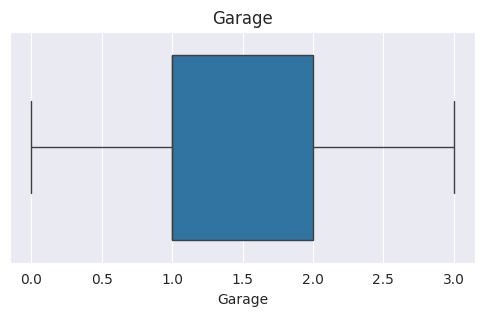

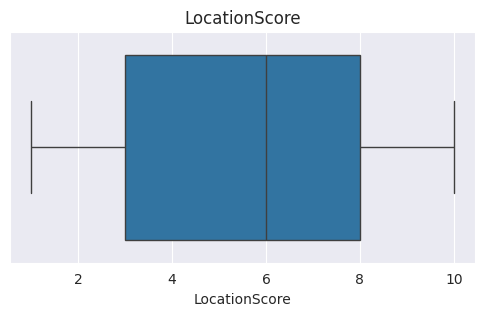

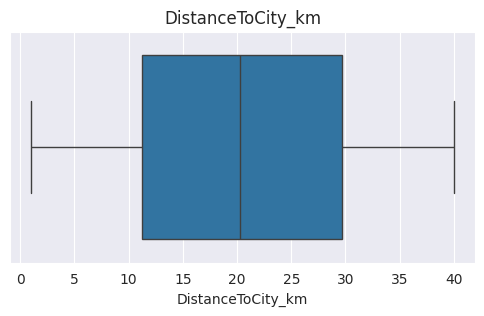

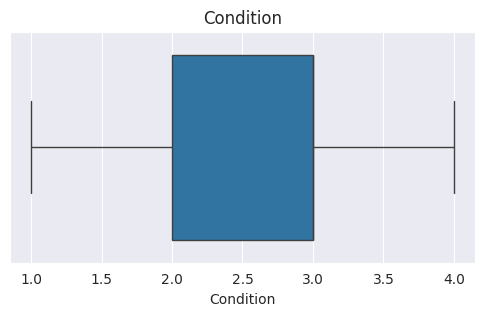

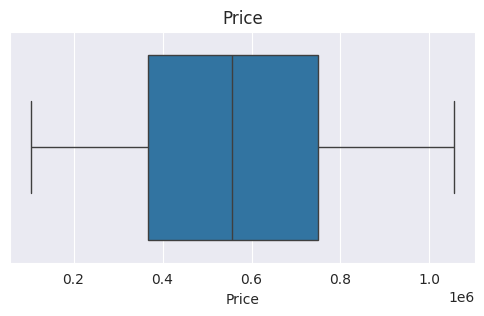

In [59]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col].dropna())
    plt.title(col)
    plt.savefig('/kaggle/working/plots/boxplot.png')
    plt.show()

### Outlier Count through IQR 

In [60]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

for col in df.select_dtypes(include=np.number).columns:
    count, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {count} outliers | Range: [{lower:.2f}, {upper:.2f}]")

Area_sqft: 0 outliers | Range: [-1246.38, 6708.62]
Bedrooms: 0 outliers | Range: [-2.50, 9.50]
Bathrooms: 0 outliers | Range: [-1.00, 7.00]
Floors: 0 outliers | Range: [-2.00, 6.00]
Age: 0 outliers | Range: [-23.00, 73.00]
Garage: 0 outliers | Range: [-0.50, 3.50]
LocationScore: 0 outliers | Range: [-4.50, 15.50]
DistanceToCity_km: 0 outliers | Range: [-16.55, 57.45]
Condition: 0 outliers | Range: [0.50, 4.50]
Price: 0 outliers | Range: [-206290.38, 1322010.62]


### KDE plot

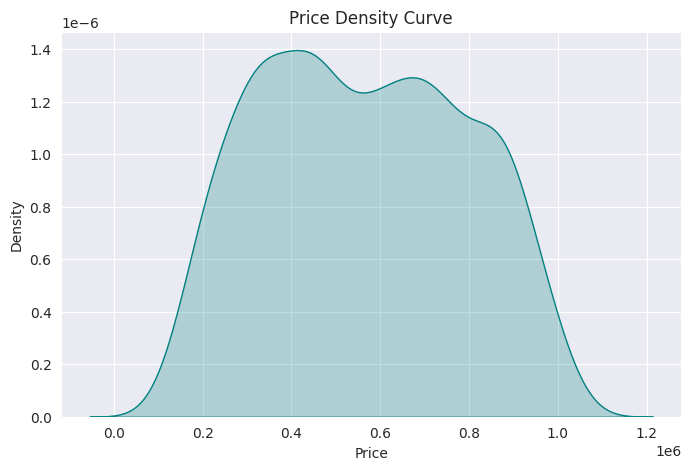

In [61]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['Price'], fill=True, color='teal')
plt.title("Price Density Curve")
plt.savefig('/kaggle/working/plots/KDE plot.png')
plt.show()

### Skewness Check

In [62]:
df.skew(numeric_only=True)

Area_sqft            0.094584
Bedrooms            -0.092252
Bathrooms           -0.172039
Floors              -0.013830
Age                 -0.022467
Garage               0.151983
LocationScore       -0.057570
DistanceToCity_km    0.043309
Condition           -0.112833
Price                0.078046
dtype: float64

### Price Distribution

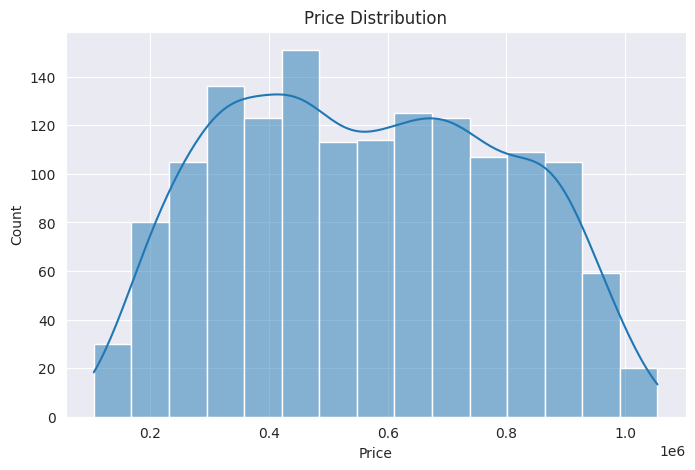

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.savefig('/kaggle/working/plots/price distribution.png')
plt.show()

### Correlation matrix (In Numbers)

In [64]:
df.corr(numeric_only=True)

,Area_sqft,Bedrooms,Bathrooms,Floors,Age,Garage,LocationScore,DistanceToCity_km,Condition,Price
Area_sqft,1.000000,0.037335,0.012210,-0.011746,-0.009077,-0.023212,-0.000475,0.050085,-0.029863,0.939382
Bedrooms,0.037335,1.000000,0.016644,-0.040601,-0.068761,-0.027828,0.030674,-0.005360,0.011347,0.099835
Bathrooms,0.012210,0.016644,1.000000,-0.052504,0.004577,-0.010948,0.007067,0.002328,-0.004895,0.051005
Floors,-0.011746,-0.040601,-0.052504,1.000000,0.037667,-0.036489,-0.030505,0.033925,-0.033223,-0.017322
Age,-0.009077,-0.068761,0.004577,0.037667,1.000000,0.025323,-0.008777,0.034264,-0.004133,-0.076687
Garage,-0.023212,-0.027828,-0.010948,-0.036489,0.025323,1.000000,-0.026509,-0.007510,0.003710,0.005089
LocationScore,-0.000475,0.030674,0.007067,-0.030505,-0.008777,-0.026509,1.000000,-0.023446,0.017650,0.146496
DistanceToCity_km,0.050085,-0.005360,0.002328,0.033925,0.034264,-0.007510,-0.023446,1.000000,-0.026201,-0.013594
Condition,-0.029863,0.011347,-0.004895,-0.033223,-0.004133,0.003710,0.017650,-0.026201,1.000000,-0.024117
Price,0.939382,0.099835,0.051005,-0.017322,-0.076687,0.005089,0.146496,-0.013594,-0.024117,1.000000


### Correlation heatmap (visual)

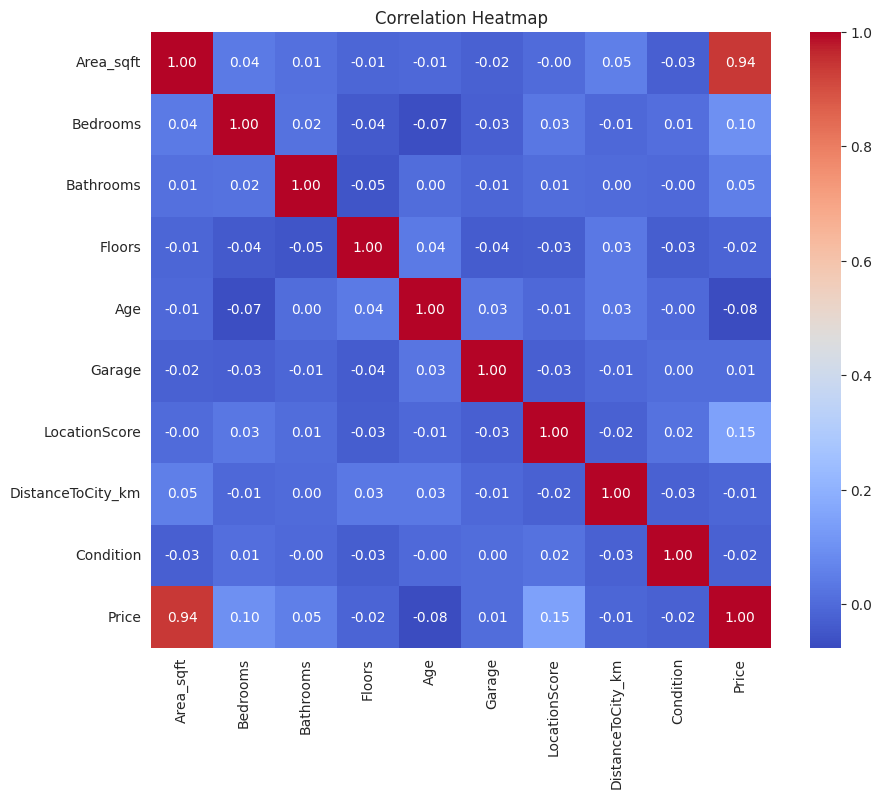

In [65]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig('/kaggle/working/plots/correlation heatmap.png')
plt.show()

### Correlation ranking with price

In [66]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price                1.000000
Area_sqft            0.939382
LocationScore        0.146496
Bedrooms             0.099835
Bathrooms            0.051005
Garage               0.005089
DistanceToCity_km   -0.013594
Floors              -0.017322
Condition           -0.024117
Age                 -0.076687
Name: Price, dtype: float64

### Scatter plots (Every feature Vs Price)

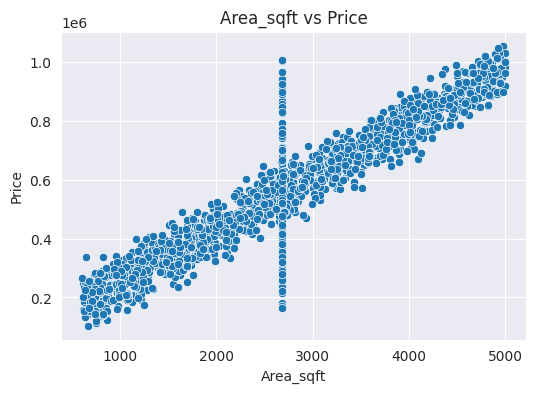

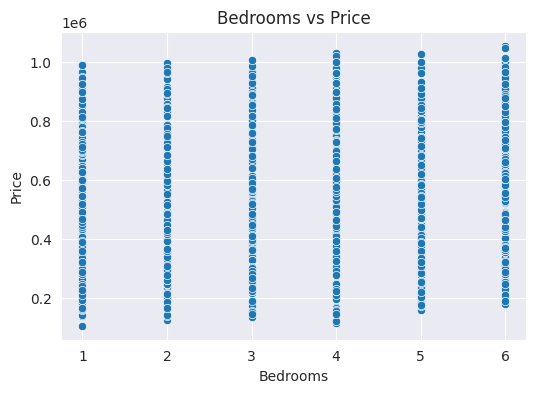

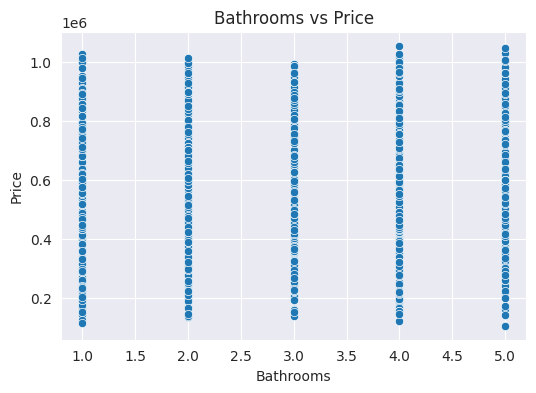

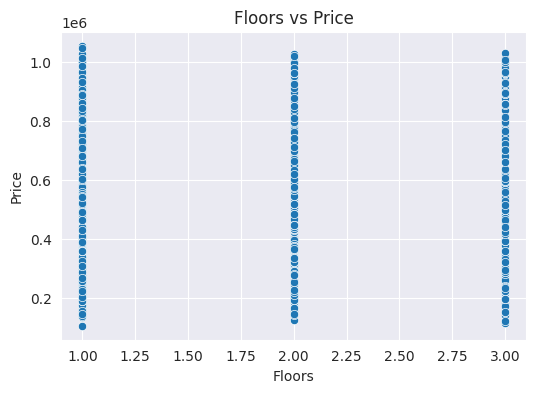

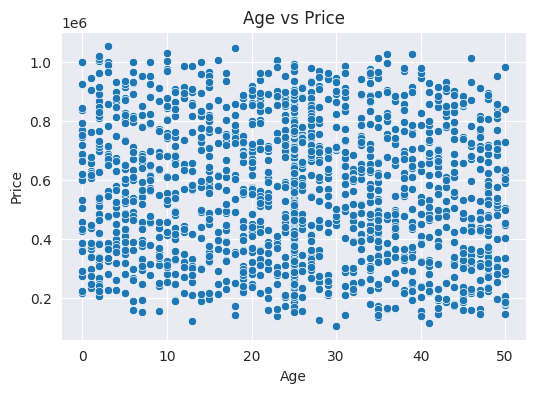

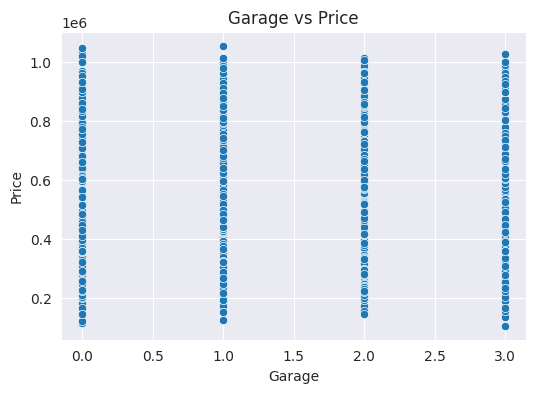

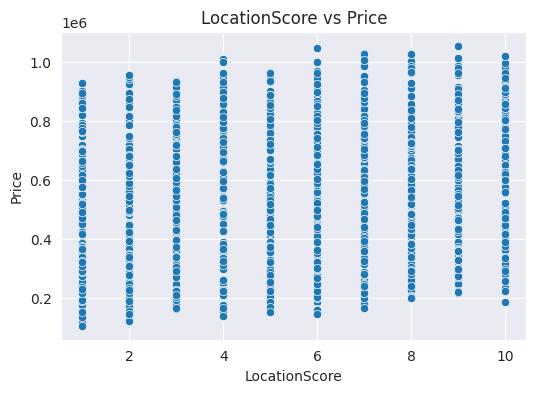

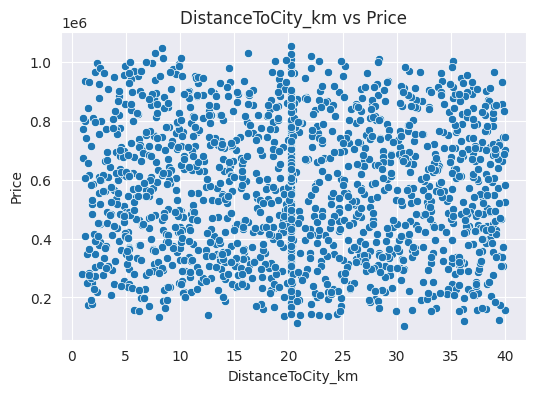

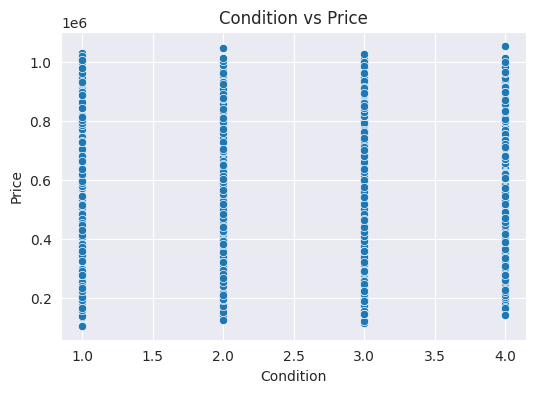

In [67]:
numeric_features = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Floors', 'Age', 
                     'Garage', 'LocationScore', 'DistanceToCity_km', 'Condition']

for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f"{col} vs Price")
    plt.savefig('/kaggle/working/plots/scatter plots.png')
    plt.show()

### Avg Price According to bedrooms

In [68]:
df.groupby('Bedrooms')['Price'].mean().sort_values(ascending=False)

Bedrooms
6.0    607087.981982
4.0    585206.029973
5.0    562549.051064
2.0    538315.843478
3.0    535633.585903
1.0    534059.858447
Name: Price, dtype: float64

### Avg Price According to condition

In [69]:
df.groupby('Condition')['Price'].mean().sort_values(ascending=False)

Condition
1.0    584920.218935
4.0    574120.275660
2.0    556459.789625
3.0    543321.000000
Name: Price, dtype: float64

### Price comparison according to garage availability

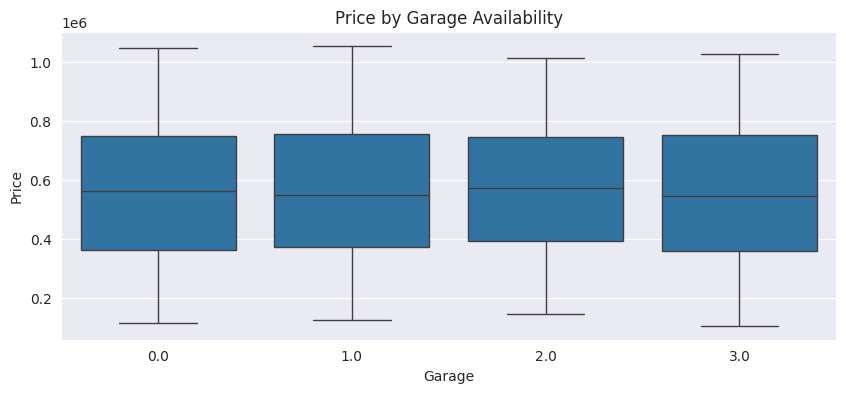

In [70]:
sns.boxplot(x='Garage', y='Price', data=df)
plt.title("Price by Garage Availability")
plt.savefig('/kaggle/working/plots/price comparison according to garage availability.png')
plt.show()

### PairPlot -- Every Numeric Features relationships together

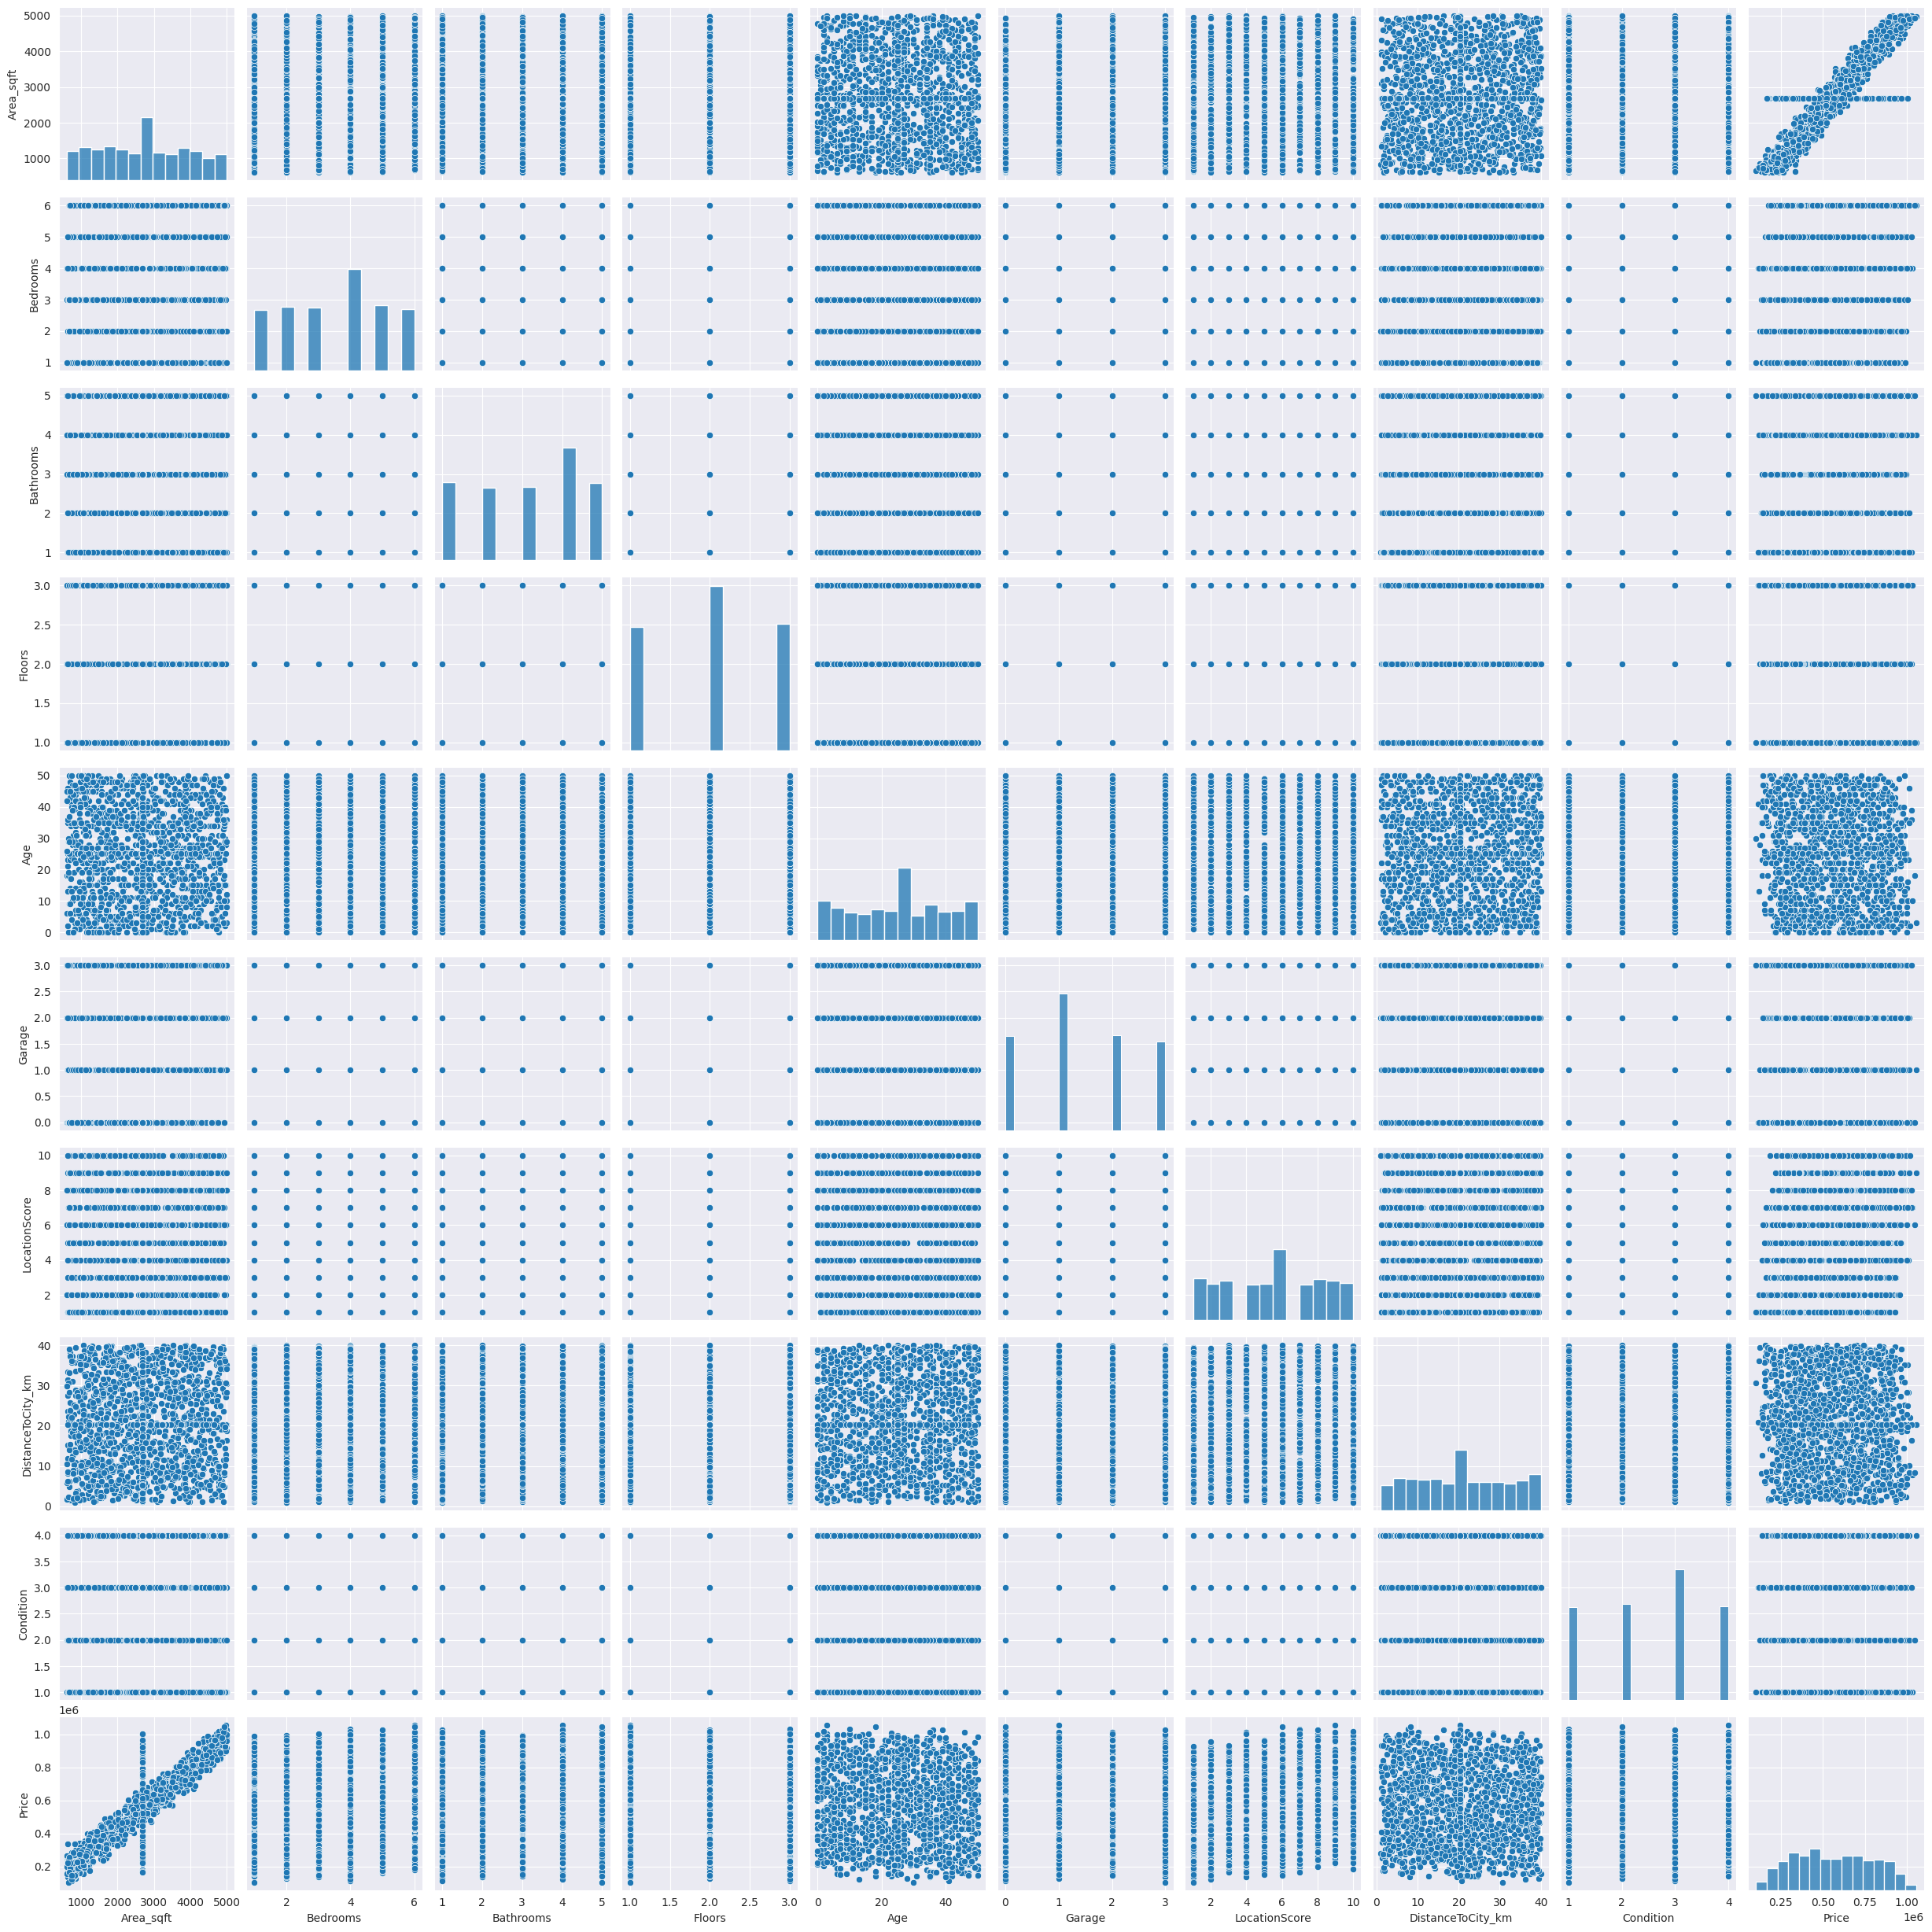

In [71]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.savefig('/kaggle/working/plots/pair plot.png')
plt.show()

<h1 style="background: linear-gradient(135deg, #f7971e 0%, #ffd200 50%, #21d4fd 100%);
           -webkit-background-clip: text;
           -webkit-text-fill-color: transparent;
           background-clip: text;
           font-size: 40px;
           font-weight: 800;
           text-align: center;
           font-family: 'Segoe UI', sans-serif;
           padding: 15px 0;
           margin: 0;">
    🧹 Data Preprocessing
</h1>

## Encoding

In [72]:
le = LabelEncoder()
df['Condition'] = le.fit_transform(df['Condition'])
df.head(1)

,Area_sqft,Bedrooms,Bathrooms,Floors,Age,Garage,LocationScore,DistanceToCity_km,Condition,Price
0,2728.0,1.0,4.0,2.0,7.0,0.0,3.0,20.25,1,547397


## Feature and Target split

In [73]:
X = df.drop('Price', axis=1)
y = df['Price']

## Train Test Split

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1200, 9), (300, 9), (1200,), (300,))

## Scaling

In [75]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

<h1 style="background: linear-gradient(135deg, #667eea 0%, #00c6ff 50%, #43e97b 100%);
           -webkit-background-clip: text;
           -webkit-text-fill-color: transparent;
           background-clip: text;
           font-size: 40px;
           font-weight: 800;
           text-align: center;
           font-family: 'Segoe UI', sans-serif;
           padding: 15px 0;
           margin: 0;">
    🤖 Model Building
</h1>

In [76]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge':Ridge(),
    'Lasso':Lasso(),
    'ElasticNet':ElasticNet(),
    'RandomForestRegressor':RandomForestRegressor(),
    'GradientBoostingRegressor': GradientBoostingRegressor(),
    'AdaBoostRegressor':AdaBoostRegressor(),
    'SVR':SVR(),
    'KNeighborsRegressor':KNeighborsRegressor()
}

## Train all models and choose the best one

In [77]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    results.append({
        'Model': name, 'RMSE': rmse, 'MAE': mae,
        'R2': r2, 'CV_R2_mean': cv_scores.mean()
    })
    fitted_models[name] = model

    print(f"{name:20s} | RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R2: {r2:.4f} | CV R2: {cv_scores.mean():.4f}")

LinearRegression     | RMSE: 76,252.73 | MAE: 42,192.58 | R2: 0.8899 | CV R2: 0.9202
Ridge                | RMSE: 76,237.17 | MAE: 42,164.82 | R2: 0.8899 | CV R2: 0.9202
Lasso                | RMSE: 76,252.55 | MAE: 42,192.29 | R2: 0.8899 | CV R2: 0.9202
ElasticNet           | RMSE: 102,348.86 | MAE: 80,372.75 | R2: 0.8016 | CV R2: 0.8158
RandomForestRegressor | RMSE: 80,018.79 | MAE: 45,524.68 | R2: 0.8787 | CV R2: 0.9005
GradientBoostingRegressor | RMSE: 75,960.93 | MAE: 41,792.70 | R2: 0.8907 | CV R2: 0.9103
AdaBoostRegressor    | RMSE: 85,595.62 | MAE: 57,426.55 | R2: 0.8613 | CV R2: 0.8746
SVR                  | RMSE: 230,585.33 | MAE: 200,019.40 | R2: -0.0069 | CV R2: -0.0020
KNeighborsRegressor  | RMSE: 109,485.41 | MAE: 82,330.62 | R2: 0.7730 | CV R2: 0.7767


In [78]:
results_df = pd.DataFrame(results).sort_values('R2',ascending=False).reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2,CV_R2_mean
0,GradientBoostingRegressor,75960.933574,41792.702484,0.890734,0.910310
1,Ridge,76237.172922,42164.815005,0.889938,0.920182
2,Lasso,76252.552476,42192.286260,0.889893,0.920181
3,LinearRegression,76252.733011,42192.579426,0.889893,0.920182
4,RandomForestRegressor,80018.790532,45524.681233,0.878748,0.900510
5,AdaBoostRegressor,85595.615455,57426.548493,0.861258,0.874582
6,ElasticNet,102348.855319,80372.749470,0.801633,0.815816
7,KNeighborsRegressor,109485.405788,82330.618000,0.773005,0.776653
8,SVR,230585.334752,200019.401888,-0.006857,-0.002031


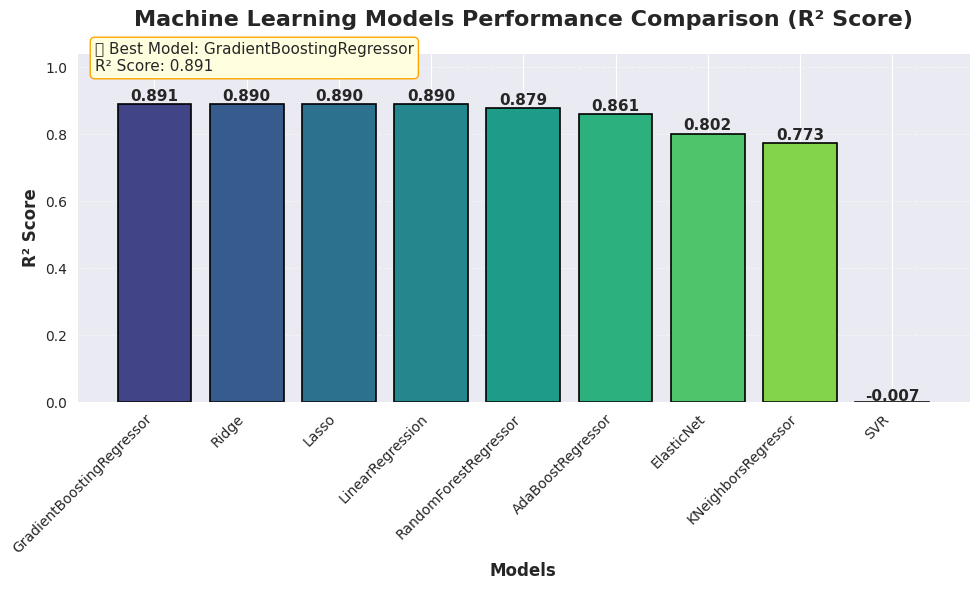

In [79]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Sort data
plot_df = results_df.sort_values("R2", ascending=False)

# Create figure
plt.figure(figsize=(10, 6))

# Gradient colors
colors = cm.viridis(np.linspace(0.2, 0.9, len(plot_df)))

# Bar chart
bars = plt.bar(
    plot_df["Model"],
    plot_df["R2"],
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Title and labels
plt.title(
    "Machine Learning Models Performance Comparison (R² Score)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Models", fontsize=12, fontweight="bold")
plt.ylabel("R² Score", fontsize=12, fontweight="bold")

# Rotate model names
plt.xticks(rotation=45, ha="right")

# Set Y limit
plt.ylim(0, max(plot_df["R2"]) + 0.15)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Remove borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Add best model highlight
best_model = plot_df.iloc[0]["Model"]
best_score = plot_df.iloc[0]["R2"]

plt.text(
    0.02,
    0.95,
    f"🏆 Best Model: {best_model}\nR² Score: {best_score:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(
        boxstyle="round",
        facecolor="lightyellow",
        edgecolor="orange"
    )
)

plt.tight_layout()
plt.show()

## HyperTune Gradient boosting regression

In [80]:
param_grid = {
    'n_estimators': [100,200,300],
    'learning_rate': [0.01,0.05,0.1],
    'max_depth': [2,3,4],
    'subsample': [0.8,1.0]
}


In [81]:
grid = GridSearchCV(
    estimator = GradientBoostingRegressor(),
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2',
    verbose = 1
)
    


In [82]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [83]:
grid.best_params_

{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}

In [84]:
grid.best_score_

np.float64(0.9131860532198125)

In [85]:
grid.best_estimator_

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=200,
                          subsample=0.8)

## Best Model Final Training

In [86]:
best_model = grid.best_estimator_

In [87]:
# train the best modal
best_model.fit(X_train,y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=200,
                          subsample=0.8)

In [88]:
# predict
y_pred = best_model.predict(X_test)

In [89]:
# Scoring
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2s = r2_score(y_test,y_pred)

print("*"*40)
print(f'Mean Squared Error : {mse:.2f}')
print(f'Mean Absolute Error : {mae:.2f}')
print(f'R-2 score : {r2s:.2f}')
print("*"*40)

****************************************
Mean Squared Error : 5752085339.37
Mean Absolute Error : 40504.24
R-2 score : 0.89
****************************************


<h1 style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 50%, #00d2ff 100%);
           -webkit-background-clip: text;
           -webkit-text-fill-color: transparent;
           background-clip: text;
           font-size: 40px;
           font-weight: 800;
           text-align: center;
           font-family: 'Segoe UI', sans-serif;
           padding: 15px 0;
           margin: 0;">
    💾 Save Model with Encoding and Scaling

In [93]:

import joblib

artifact = {
    'Best Model': best_model,
    'Encoding': le,
    'Scaling': sc
}
joblib.dump(artifact, '/kaggle/working/models/artifact.pkl')

['/kaggle/working/models/artifact.pkl']

In [97]:
import shutil
import os

os.makedirs('/kaggle/working/download_folder', exist_ok=True)


shutil.copytree('/kaggle/working/models', '/kaggle/working/download_folder/models', dirs_exist_ok=True)
shutil.copytree('/kaggle/working/plots', '/kaggle/working/download_folder/plots', dirs_exist_ok=True)

'/kaggle/working/download_folder/plots'

In [98]:
shutil.make_archive('/kaggle/working/models_and_plots', 'zip', '/kaggle/working/download_folder')

'/kaggle/working/models_and_plots.zip'

In [99]:
import os
print(os.path.exists('/kaggle/working/models_and_plots.zip'))
print(round(os.path.getsize('/kaggle/working/models_and_plots.zip') / 1024, 2), "KB")

True
1417.42 KB
